# Análisis Histórico de Ventas — Rumbo Verde
**Período:** Enero 2025 – Abril 2026  
**Fuente:** Bsale (tienda física + delivery + online)  
**Autor:** Tu nombre  

## Objetivo
Analizar la evolución de ventas por canal, tendencias mensuales 
y patrones de comportamiento del negocio en 16 meses consecutivos.


In [12]:
# ─────────────────────────────────────────────────
# LIBRERÍAS
# ─────────────────────────────────────────────────

import pandas as pd           # manejo de tablas y datos
import matplotlib.pyplot as plt  # crear gráficos
import matplotlib.ticker as mticker  # formatear ejes de gráficos
import seaborn as sns          # gráficos más visuales (heatmap)
import numpy as np             # cálculos matemáticos
import warnings
warnings.filterwarnings('ignore')  # oculta advertencias menores

# Configuración visual de los gráficos
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
    'figure.facecolor' : '#FAFAFA',
    'axes.facecolor'   : '#FAFAFA',
})

# Paleta de colores del proyecto
VERDE  = '#2D7A4F'
AZUL   = '#2563EB'
NARANJ = '#F59E0B'
ROJO   = '#EF4444'
GRIS   = '#94A3B8'

print("✅ Librerías listas")

✅ Librerías listas


In [13]:
# ─────────────────────────────────────────────────
# CONFIGURACIÓN DE RUTAS
# ─────────────────────────────────────────────────

# Aquí le decimos a Python dónde están los archivos.
# El '../' significa "sube un nivel desde notebooks/ 
# y busca ahí" — así llega a la carpeta data/

BSALE_2025      = '../data/Ventas_2025.xlsx'
BSALE_2026      = '../data/Ventas_2026.xlsx'
JUMPSELLER_2025 = '../data/pedidos_2025.csv'
JUMPSELLER_2026 = '../data/pedidos_2026.csv'
OUTPUT_DIR      = '../outputs/'

print("✅ Rutas configuradas")

✅ Rutas configuradas


In [14]:
# ─────────────────────────────────────────────────
# PASO 1 — Unir y limpiar datos Bsale (2025-2026)
# ─────────────────────────────────────────────────

# 1.1 Cargar y unir los dos archivos
# pd.read_excel lee un archivo Excel y lo convierte en tabla
# pd.concat apila dos tablas una debajo de la otra
df25 = pd.read_excel(BSALE_2025)
df26 = pd.read_excel(BSALE_2026)
df   = pd.concat([df25, df26], ignore_index=True)

print(f"📦 Bsale 2025: {len(df25):,} filas")
print(f"📦 Bsale 2026: {len(df26):,} filas")
print(f"📦 Total unido: {len(df):,} filas")

📦 Bsale 2025: 30,940 filas
📦 Bsale 2026: 8,888 filas
📦 Total unido: 39,828 filas


In [15]:
# ─────────────────────────────────────────────────
# 1.2 Separar ventas de devoluciones
# ─────────────────────────────────────────────────

# El archivo tiene dos tipos de movimiento: ventas y devoluciones
# Las separamos para no mezclarlas al calcular totales
# .copy() crea una copia independiente para no afectar la tabla original

ventas       = df[df['Tipo Movimiento'] == 'venta'].copy()
devoluciones = df[df['Tipo Movimiento'] == 'devolucion'].copy()

print(f"✅ Ventas:       {len(ventas):,} filas")
print(f"✅ Devoluciones: {len(devoluciones):,} filas")

✅ Ventas:       39,722 filas
✅ Devoluciones: 104 filas


In [16]:
# ─────────────────────────────────────────────────
# 1.3 Convertir fechas y agregar columnas de tiempo
# ─────────────────────────────────────────────────

# El Excel guarda la fecha como texto "01/04/2026"
# pd.to_datetime la convierte a fecha real para poder 
# ordenar, filtrar y agrupar por mes, año, día, etc.

ventas['fecha_dt'] = pd.to_datetime(ventas['Fecha Venta'], format='%d/%m/%Y')

# Ahora extraemos partes útiles de la fecha
# Así podemos agrupar por mes o año fácilmente después

ventas['año']        = ventas['fecha_dt'].dt.year
ventas['mes']        = ventas['fecha_dt'].dt.month
ventas['mes_año']    = ventas['fecha_dt'].dt.to_period('M')  # ej: 2025-04
ventas['dia_semana'] = ventas['fecha_dt'].dt.day_name().map({
    'Monday'   : 'Lunes',
    'Tuesday'  : 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday' : 'Jueves',
    'Friday'   : 'Viernes',
    'Saturday' : 'Sábado',
    'Sunday'   : 'Domingo'
})

print(f"✅ Fechas convertidas correctamente")
print(f"📅 Período: {ventas['fecha_dt'].min().date()} → {ventas['fecha_dt'].max().date()}")
print(f"📅 Meses disponibles: {ventas['mes_año'].nunique()}")

✅ Fechas convertidas correctamente
📅 Período: 2025-01-02 → 2026-04-30
📅 Meses disponibles: 16


In [25]:
# ─────────────────────────────────────────────────
# 1.4 Clasificar canales de venta
# ─────────────────────────────────────────────────

# Con los datos disponibles podemos distinguir 2 canales en Bsale:
# - Tienda física + Online: todo lo que no es delivery
# - Delivery: ventas con lista de precio Uber/Rappi/MercadoLibre

# Nota: Bsale no registra por separado tienda física de online
# Jumpseller se usará solo para análisis de detalle de pedidos online
# (productos, ciudades, métodos de envío) nunca para sumar montos

def clasificar_canal(lista_precio):
    # Si el campo está vacío es tienda/online
    if pd.isna(lista_precio):
        return 'Tienda / Online'
    lp = lista_precio.upper()
    # Si contiene estas palabras es delivery
    if any(x in lp for x in ['UBER', 'RAPPI', 'ML FULL']):
        return 'Delivery'
    return 'Tienda / Online'

ventas['canal'] = ventas['Lista de Precio'].apply(clasificar_canal)

# Verificar resultado
resumen = ventas.groupby('canal').agg(
    boletas    = ('Numero del documento', 'nunique'),
    venta_neta = ('Venta Total Neta', 'sum'),
    margen     = ('% Margen', 'mean')
).reset_index()
resumen['porcentaje']  = (resumen['venta_neta'] / resumen['venta_neta'].sum() * 100).round(1)
resumen['venta_neta']  = (resumen['venta_neta'] / 1e6).round(2)
resumen['margen']      = (resumen['margen'] * 100).round(1)
resumen.columns = ['Canal','Boletas','Venta Neta (M CLP)','Margen %','% del total']

print("✅ Canales clasificados:")
print(resumen.to_string(index=False))

✅ Canales clasificados:
          Canal  Boletas  Venta Neta (M CLP)  Margen %  % del total
       Delivery     2789               69.90      50.0         14.6
Tienda / Online    13522              409.46      42.1         85.4


In [26]:
# ─────────────────────────────────────────────────
# 1.5 Resumen final — tabla limpia y lista
# ─────────────────────────────────────────────────

# Calculamos la venta neta real descontando devoluciones
total_ventas     = ventas['Venta Total Neta'].sum()
total_devoluc    = devoluciones['Venta Total Neta'].sum()
total_neto_real  = total_ventas + total_devoluc  # devoluciones ya vienen negativas

print("=" * 50)
print("  RESUMEN — DATOS LISTOS PARA ANALIZAR")
print("=" * 50)
print(f"  Período:           Ene 2025 → Abr 2026")
print(f"  Meses:             {ventas['mes_año'].nunique()} meses consecutivos")
print(f"  Líneas de venta:   {len(ventas):,}")
print(f"  Boletas únicas:    {ventas['Numero del documento'].nunique():,}")
print(f"  Devoluciones:      {len(devoluciones):,}")
print(f"  Venta neta total:  ${total_neto_real/1e6:.2f}M CLP")
print(f"  Margen promedio:   {ventas['% Margen'].mean()*100:.1f}%")
print("=" * 50)
print()
print("  Canales disponibles:")
print(f"  - Tienda / Online: 85.4% del total")
print(f"  - Delivery:        14.6% del total")
print()
print("✅ Paso 1 completo — datos listos para análisis")

  RESUMEN — DATOS LISTOS PARA ANALIZAR
  Período:           Ene 2025 → Abr 2026
  Meses:             16 meses consecutivos
  Líneas de venta:   39,722
  Boletas únicas:    16,308
  Devoluciones:      104
  Venta neta total:  $471.40M CLP
  Margen promedio:   43.1%

  Canales disponibles:
  - Tienda / Online: 85.4% del total
  - Delivery:        14.6% del total

✅ Paso 1 completo — datos listos para análisis


In [27]:
# ─────────────────────────────────────────────────
# PASO 2 — Tendencia mensual de ventas
# ─────────────────────────────────────────────────

# Agrupamos las ventas por mes sumando la venta neta
# .groupby() es como una tabla dinámica en Excel
# agrupa todas las filas del mismo mes y las suma

por_mes = ventas.groupby('mes_año').agg(
    venta_neta  = ('Venta Total Neta', 'sum'),
    boletas     = ('Numero del documento', 'nunique'),
    margen_prom = ('% Margen', 'mean')
).reset_index()

# Convertir a millones para que el gráfico sea más legible
por_mes['venta_M']     = por_mes['venta_neta'] / 1e6
por_mes['mes_str']     = por_mes['mes_año'].astype(str)
por_mes['margen_pct']  = por_mes['margen_prom'] * 100

print("=== VENTAS POR MES ===")
print(por_mes[['mes_str','venta_M','boletas','margen_pct']].to_string(index=False))

=== VENTAS POR MES ===
mes_str   venta_M  boletas  margen_pct
2025-01 29.335467      933   42.788220
2025-02 24.296063      768   45.246015
2025-03 29.421475     1058   44.648099
2025-04 32.399362     1115   43.535288
2025-05 34.869557     1108   43.640577
2025-06 34.330025     1141   43.822586
2025-07 34.009456     1166   44.174608
2025-08 37.440819     1197   44.881931
2025-09 29.534876     1000   44.972609
2025-10 28.194701     1020   44.512976
2025-11 29.227055      933   42.182944
2025-12 26.115632      855   42.570991
2026-01 26.809592      923   41.501461
2026-02 22.666416      874   38.242486
2026-03 32.386257     1182   38.586939
2026-04 28.325532     1060   41.555648


Text(0.0, 1.0, 'Margen Promedio Mensual')

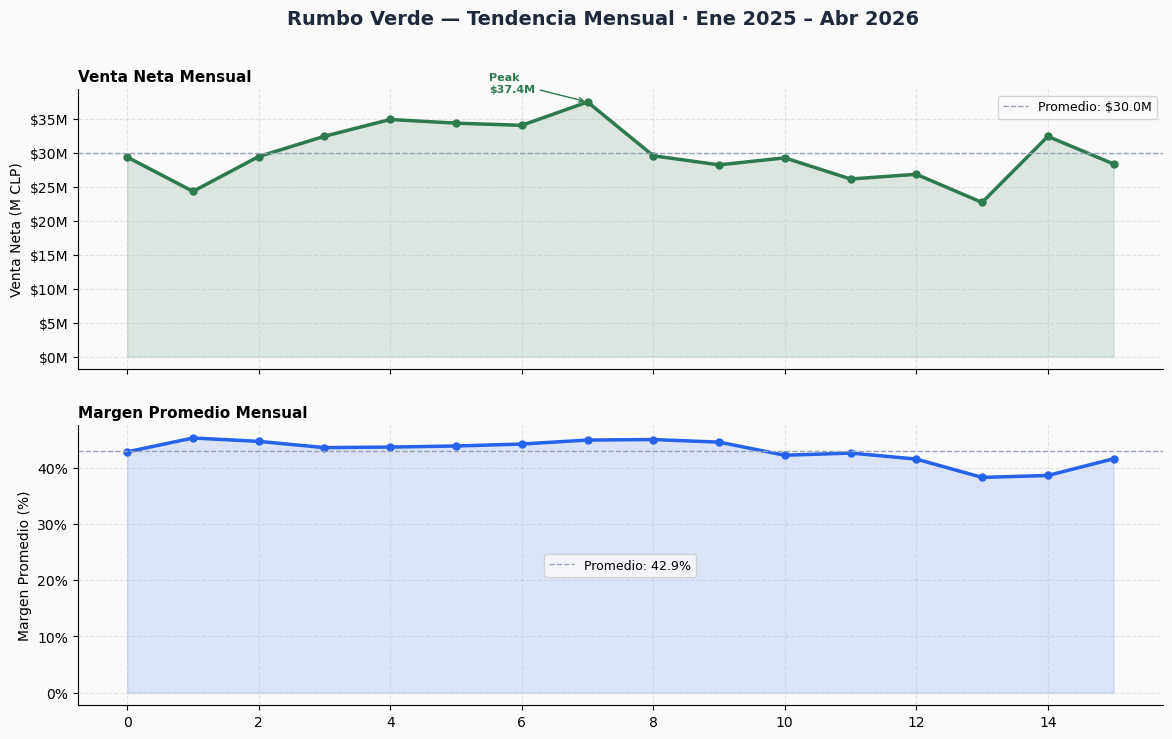

In [28]:
# ─────────────────────────────────────────────────
# PASO 2 — Gráfico de tendencia mensual
# ─────────────────────────────────────────────────

# Creamos una figura con dos gráficos apilados
# El de arriba muestra ventas, el de abajo el margen
# Así vemos si cuando suben las ventas el margen se mantiene

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Rumbo Verde — Tendencia Mensual · Ene 2025 – Abr 2026',
             fontsize=14, fontweight='bold', color='#1E293B')

x = range(len(por_mes))

# ── Gráfico 1: Ventas mensuales ──
# fill_between rellena el área bajo la línea
ax1.fill_between(x, por_mes['venta_M'], alpha=0.15, color=VERDE)
ax1.plot(x, por_mes['venta_M'], color=VERDE, linewidth=2.5, marker='o', markersize=5)

# Línea de promedio para referencia
promedio = por_mes['venta_M'].mean()
ax1.axhline(promedio, color=GRIS, linewidth=1, linestyle='--', label=f'Promedio: ${promedio:.1f}M')

# Destacar el mes peak
idx_max = por_mes['venta_M'].idxmax()
ax1.annotate(f"Peak\n${por_mes['venta_M'][idx_max]:.1f}M",
             xy=(idx_max, por_mes['venta_M'][idx_max]),
             xytext=(idx_max - 1.5, por_mes['venta_M'][idx_max] + 1.5),
             fontsize=8, color=VERDE, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=VERDE))

ax1.set_ylabel('Venta Neta (M CLP)', fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax1.legend(fontsize=9)
ax1.set_title('Venta Neta Mensual', fontsize=11, fontweight='bold', loc='left')

# ── Gráfico 2: Margen mensual ──
ax2.fill_between(x, por_mes['margen_pct'], alpha=0.15, color=AZUL)
ax2.plot(x, por_mes['margen_pct'], color=AZUL, linewidth=2.5, marker='o', markersize=5)

# Línea de promedio margen
prom_margen = por_mes['margen_pct'].mean()
ax2.axhline(prom_margen, color=GRIS, linewidth=1, linestyle='--',
            label=f'Promedio: {prom_margen:.1f}%')

ax2.set_ylabel('Margen Promedio (%)', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2.legend(fontsize=9)
ax2.set_title('Margen Promedio Mensual', fontsize=11, fontweight='bold', loc='left')

# ── Etiquetas del e

In [29]:
# ─────────────────────────────────────────────────
# PASO 3 — Comparativa 2025 vs 2026
# ─────────────────────────────────────────────────

# Solo podemos comparar los meses que existen en ambos años
# enero a abril — que es lo que tenemos de 2026

# Filtramos solo esos 4 meses en cada año
meses_comparables = [1, 2, 3, 4]

v2025 = ventas[(ventas['año'] == 2025) & (ventas['mes'].isin(meses_comparables))]
v2026 = ventas[(ventas['año'] == 2026) & (ventas['mes'].isin(meses_comparables))]

# Agrupamos por mes para tener el total de cada uno
comp2025 = v2025.groupby('mes')['Venta Total Neta'].sum().reset_index()
comp2026 = v2026.groupby('mes')['Venta Total Neta'].sum().reset_index()

# Unimos las dos tablas en una sola para comparar fácilmente
# suffixes le pone _2025 y _2026 a las columnas duplicadas
comp = comp2025.merge(comp2026, on='mes', suffixes=('_2025','_2026'))
comp['variacion_%'] = ((comp['Venta Total Neta_2026'] - comp['Venta Total Neta_2025']) 
                       / comp['Venta Total Neta_2025'] * 100).round(1)
comp['mes_nombre'] = ['Enero','Febrero','Marzo','Abril']
comp['v2025_M'] = (comp['Venta Total Neta_2025'] / 1e6).round(2)
comp['v2026_M'] = (comp['Venta Total Neta_2026'] / 1e6).round(2)

print("=== COMPARATIVA ENE–ABR: 2025 vs 2026 ===")
print(comp[['mes_nombre','v2025_M','v2026_M','variacion_%']].to_string(index=False))
print()
print(f"Total Ene–Abr 2025: ${comp['v2025_M'].sum():.2f}M")
print(f"Total Ene–Abr 2026: ${comp['v2026_M'].sum():.2f}M")
variacion_total = ((comp['v2026_M'].sum() - comp['v2025_M'].sum()) / comp['v2025_M'].sum() * 100)
print(f"Variación total:    {variacion_total:.1f}%")

=== COMPARATIVA ENE–ABR: 2025 vs 2026 ===
mes_nombre  v2025_M  v2026_M  variacion_%
     Enero    29.34    26.81         -8.6
   Febrero    24.30    22.67         -6.7
     Marzo    29.42    32.39         10.1
     Abril    32.40    28.33        -12.6

Total Ene–Abr 2025: $115.46M
Total Ene–Abr 2026: $110.20M
Variación total:    -4.6%


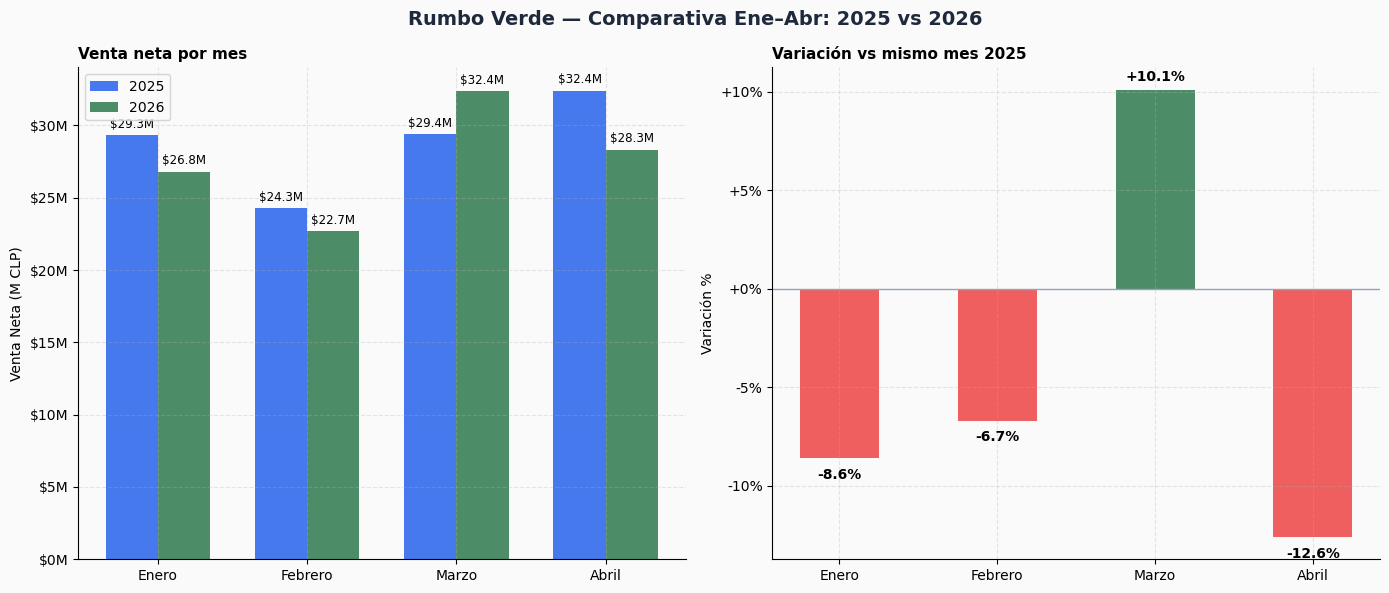

✅ Gráfico guardado en outputs/


In [30]:
# ─────────────────────────────────────────────────
# PASO 3 — Gráfico comparativa 2025 vs 2026
# ─────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Rumbo Verde — Comparativa Ene–Abr: 2025 vs 2026',
             fontsize=14, fontweight='bold', color='#1E293B')

x      = np.arange(len(comp))
ancho  = 0.35
meses  = comp['mes_nombre']

# ── Gráfico 1: Barras agrupadas 2025 vs 2026 ──
# Las barras agrupadas permiten comparar visualmente cada mes
barras_2025 = ax1.bar(x - ancho/2, comp['v2025_M'], ancho,
                      label='2025', color=AZUL, alpha=0.85)
barras_2026 = ax1.bar(x + ancho/2, comp['v2026_M'], ancho,
                      label='2026', color=VERDE, alpha=0.85)

# Agregar el valor encima de cada barra
for bar in barras_2025:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.3,
             f'${h:.1f}M', ha='center', va='bottom', fontsize=8.5)
for bar in barras_2026:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.3,
             f'${h:.1f}M', ha='center', va='bottom', fontsize=8.5)

ax1.set_xticks(x)
ax1.set_xticklabels(meses, fontsize=10)
ax1.set_ylabel('Venta Neta (M CLP)', fontsize=10)
ax1.set_title('Venta neta por mes', fontsize=11, fontweight='bold', loc='left')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax1.legend(fontsize=10)

# ── Gráfico 2: Variación porcentual ──
# Coloreamos en verde si creció y en rojo si cayó
colores_var = [VERDE if v > 0 else ROJO for v in comp['variacion_%']]
barras_var  = ax2.bar(x, comp['variacion_%'], color=colores_var, alpha=0.85, width=0.5)

# Línea de referencia en 0
ax2.axhline(0, color=GRIS, linewidth=1)

# Valor encima o debajo de cada barra
for bar, val in zip(barras_var, comp['variacion_%']):
    offset = 0.3 if val > 0 else -1.2
    ax2.text(bar.get_x() + bar.get_width()/2, val + offset,
             f'{val:+.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(meses, fontsize=10)
ax2.set_ylabel('Variación %', fontsize=10)
ax2.set_title('Variación vs mismo mes 2025', fontsize=11, fontweight='bold', loc='left')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'rv_comparativa_2025_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado en outputs/")

In [31]:
# ─────────────────────────────────────────────────
# PASO 4 — Análisis de canales
# ─────────────────────────────────────────────────

# Agrupamos por canal y mes para ver cómo evoluciona
# cada canal a lo largo del tiempo

canal_mes = ventas.groupby(['mes_año', 'canal']).agg(
    venta_neta  = ('Venta Total Neta', 'sum'),
    boletas     = ('Numero del documento', 'nunique'),
    margen_prom = ('% Margen', 'mean')
).reset_index()

canal_mes['venta_M']    = (canal_mes['venta_neta'] / 1e6).round(2)
canal_mes['mes_str']    = canal_mes['mes_año'].astype(str)
canal_mes['margen_pct'] = (canal_mes['margen_prom'] * 100).round(1)

# Separar cada canal en su propia columna
# .pivot_table es como una tabla dinámica en Excel
pivot_canal = canal_mes.pivot_table(
    index='mes_str', 
    columns='canal', 
    values='venta_M'
).reset_index()

print("=== VENTAS POR CANAL Y MES (M CLP) ===")
print(pivot_canal.to_string(index=False))
print()
print("=== RESUMEN TOTAL POR CANAL ===")
resumen_canal = ventas.groupby('canal').agg(
    venta_neta  = ('Venta Total Neta', 'sum'),
    boletas     = ('Numero del documento', 'nunique'),
    margen_prom = ('% Margen', 'mean')
).reset_index()
resumen_canal['venta_M']    = (resumen_canal['venta_neta'] / 1e6).round(2)
resumen_canal['margen_pct'] = (resumen_canal['margen_prom'] * 100).round(1)
resumen_canal['pct_total']  = (resumen_canal['venta_neta'] / resumen_canal['venta_neta'].sum() * 100).round(1)
print(resumen_canal[['canal','boletas','venta_M','margen_pct','pct_total']].to_string(index=False))

=== VENTAS POR CANAL Y MES (M CLP) ===
mes_str  Delivery  Tienda / Online
2025-01      2.92            26.41
2025-02      3.58            20.71
2025-03      3.25            26.17
2025-04      4.15            28.25
2025-05      3.48            31.39
2025-06      4.20            30.13
2025-07      4.66            29.35
2025-08      4.58            32.86
2025-09      3.35            26.18
2025-10      4.12            24.07
2025-11      3.91            25.32
2025-12      4.41            21.71
2026-01      5.17            21.64
2026-02      4.87            17.80
2026-03      6.40            25.99
2026-04      6.84            21.49

=== RESUMEN TOTAL POR CANAL ===
          canal  boletas  venta_M  margen_pct  pct_total
       Delivery     2789    69.90        50.0       14.6
Tienda / Online    13522   409.46        42.1       85.4


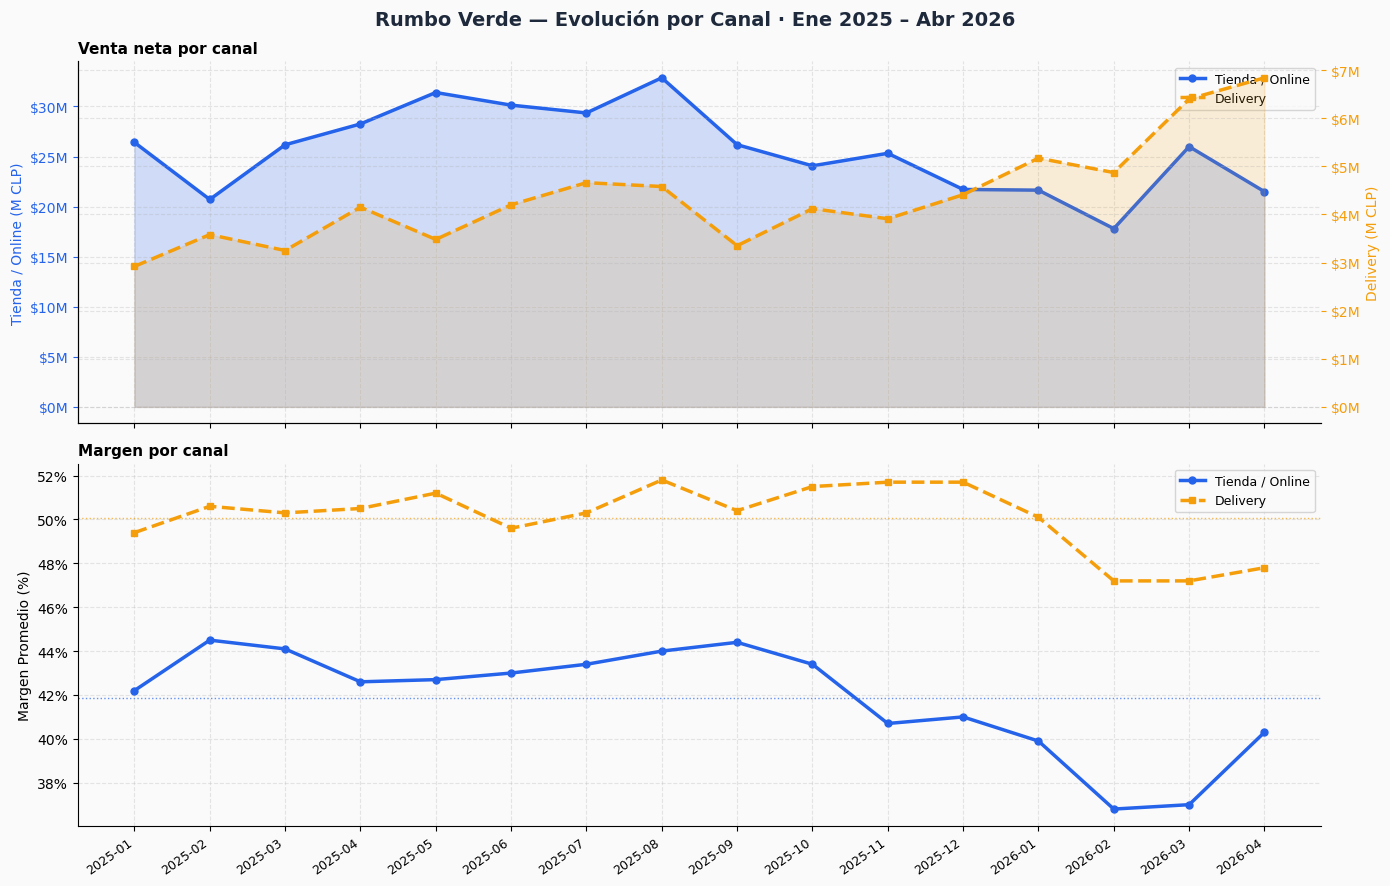

✅ Gráfico guardado en outputs/


In [32]:
# ─────────────────────────────────────────────────
# PASO 4 — Gráfico evolución de canales
# ─────────────────────────────────────────────────

# Separamos los datos de cada canal para graficarlos
tienda  = canal_mes[canal_mes['canal'] == 'Tienda / Online'].reset_index(drop=True)
delivery = canal_mes[canal_mes['canal'] == 'Delivery'].reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Rumbo Verde — Evolución por Canal · Ene 2025 – Abr 2026',
             fontsize=14, fontweight='bold', color='#1E293B')

x = range(len(tienda))

# ── Gráfico 1: Ventas por canal ──
# Área apilada — muestra el total y la proporción de cada canal
ax1.fill_between(x, tienda['venta_M'], alpha=0.2, color=AZUL)
ax1.plot(x, tienda['venta_M'], color=AZUL, linewidth=2.5,
         marker='o', markersize=5, label='Tienda / Online')

ax1_r = ax1.twinx()  # eje secundario para delivery
ax1_r.fill_between(x, delivery['venta_M'], alpha=0.15, color=NARANJ)
ax1_r.plot(x, delivery['venta_M'], color=NARANJ, linewidth=2.5,
           marker='s', markersize=5, label='Delivery', linestyle='--')
ax1_r.set_ylabel('Delivery (M CLP)', fontsize=10, color=NARANJ)
ax1_r.tick_params(axis='y', colors=NARANJ)
ax1_r.spines['top'].set_visible(False)

ax1.set_ylabel('Tienda / Online (M CLP)', fontsize=10, color=AZUL)
ax1.tick_params(axis='y', colors=AZUL)
ax1.set_title('Venta neta por canal', fontsize=11, fontweight='bold', loc='left')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax1_r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax1_r.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, fontsize=9, loc='upper right')

# ── Gráfico 2: Margen por canal ──
ax2.plot(x, tienda['margen_pct'], color=AZUL, linewidth=2.5,
         marker='o', markersize=5, label='Tienda / Online')
ax2.plot(x, delivery['margen_pct'], color=NARANJ, linewidth=2.5,
         marker='s', markersize=5, label='Delivery', linestyle='--')

prom_tienda   = tienda['margen_pct'].mean()
prom_delivery = delivery['margen_pct'].mean()
ax2.axhline(prom_tienda,   color=AZUL,   linewidth=1, linestyle=':', alpha=0.7)
ax2.axhline(prom_delivery, color=NARANJ, linewidth=1, linestyle=':', alpha=0.7)

ax2.set_ylabel('Margen Promedio (%)', fontsize=10)
ax2.set_title('Margen por canal', fontsize=11, fontweight='bold', loc='left')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2.legend(fontsize=9)

# ── Etiquetas eje X ──
ax2.set_xticks(range(len(tienda)))
ax2.set_xticklabels(tienda['mes_str'], rotation=35, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'rv_canales.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado en outputs/")

In [33]:
# ─────────────────────────────────────────────────
# PASO 5 — Top productos y marcas
# ─────────────────────────────────────────────────

# Agrupamos por producto sumando ventas, unidades y margen
# Esto nos dice qué productos generan más dinero al negocio

top_productos = ventas.groupby('Producto / Servicio').agg(
    venta_neta  = ('Venta Total Neta', 'sum'),
    unidades    = ('Cantidad', 'sum'),
    margen_prom = ('% Margen', 'mean')
).reset_index()

top_productos['venta_M']    = (top_productos['venta_neta'] / 1e6).round(2)
top_productos['margen_pct'] = (top_productos['margen_prom'] * 100).round(1)
top_productos['pct_total']  = (top_productos['venta_neta'] / top_productos['venta_neta'].sum() * 100).round(2)

# Ordenar de mayor a menor venta
top_productos = top_productos.sort_values('venta_neta', ascending=False).reset_index(drop=True)

# Calcular participación acumulada — esto es el análisis Pareto
# Pareto dice que el 20% de los productos generan el 80% de las ventas
top_productos['pct_acumulado'] = top_productos['pct_total'].cumsum().round(1)

print("=== TOP 15 PRODUCTOS POR VENTA NETA ===")
print(top_productos[['Producto / Servicio','venta_M','unidades','margen_pct','pct_total','pct_acumulado']].head(15).to_string(index=False))
print()

# Cuántos productos generan el 80% de las ventas
pareto_80 = top_productos[top_productos['pct_acumulado'] <= 80]
print(f"Total productos únicos:              {len(top_productos):,}")
print(f"Productos que generan el 80% ventas: {len(pareto_80):,}")
print(f"Eso representa el:                   {len(pareto_80)/len(top_productos)*100:.1f}% del catálogo")

=== TOP 15 PRODUCTOS POR VENTA NETA ===
                                    Producto / Servicio  venta_M  unidades  margen_pct  pct_total  pct_acumulado
                       Wellplus - Neuromag PR0 90 Caps     12.36     319.0        35.7       2.58            2.6
                 Madre Tierra - Aceite oregano oro 30ml    10.78     358.0        33.6       2.25            4.8
Wellplus - Triple Magnesio Quelado + Zinc 120 Cápsulas      8.62     408.0        36.1       1.80            6.6
                          3R - GoldenMaqui 60 capsulas      6.76     450.0        66.7       1.41            8.0
                                                  Glosa     6.25      12.0       100.0       1.30            9.3
      Nirdosh Cigarrillo Herbal - Cajetilla 20 unidades     6.24     954.0        35.3       1.30           10.6
                          Despacho Region Metropolitana     6.05    1878.0        99.9       1.26           11.9
     Wellplus - Vitamina C Plus Liposomal 90 cápsulas   

In [34]:
# ─────────────────────────────────────────────────
# PASO 5 — Limpiar productos y graficar
# ─────────────────────────────────────────────────

# Eliminamos registros que no son productos reales
# como despachos, glosas y ajustes contables
palabras_excluir = ['despacho', 'glosa', 'ajuste', 'flete', 'envio', 'envío']

mask = ~top_productos['Producto / Servicio'].str.lower().str.contains(
    '|'.join(palabras_excluir), na=False
)
productos_limpios = top_productos[mask].reset_index(drop=True)

# Recalcular porcentaje acumulado sin los registros eliminados
productos_limpios['pct_total']     = (productos_limpios['venta_neta'] / 
                                       productos_limpios['venta_neta'].sum() * 100).round(2)
productos_limpios['pct_acumulado'] = productos_limpios['pct_total'].cumsum().round(1)

print(f"Productos después de limpieza: {len(productos_limpios):,}")
print()

# Top 15 para graficar
top15 = productos_limpios.head(15).copy()

# Ahora agrupamos por marca
top_marcas = ventas[mask.reindex(ventas.index, fill_value=True)].groupby('Marca').agg(
    venta_neta  = ('Venta Total Neta', 'sum'),
    productos   = ('Producto / Servicio', 'nunique'),
    margen_prom = ('% Margen', 'mean')
).reset_index()
top_marcas['venta_M']    = (top_marcas['venta_neta'] / 1e6).round(2)
top_marcas['margen_pct'] = (top_marcas['margen_prom'] * 100).round(1)
top_marcas = top_marcas.sort_values('venta_neta', ascending=False).reset_index(drop=True)

print("=== TOP 10 MARCAS ===")
print(top_marcas[['Marca','venta_M','productos','margen_pct']].head(10).to_string(index=False))

Productos después de limpieza: 1,682

=== TOP 10 MARCAS ===
         Marca  venta_M  productos  margen_pct
      Wellplus    84.60         79        36.5
       BioCare    22.95         36        36.1
    newscience    20.87         33        38.2
  Madre Tierra    18.06         18        34.8
       DoTerra    13.56         39        41.5
     Eden Shot    12.74          6        38.6
      Giovegen    12.08          5        38.0
            3R    11.95          6        58.1
       Nirdosh     8.77          2        35.2
My Green Power     8.77          3        36.3


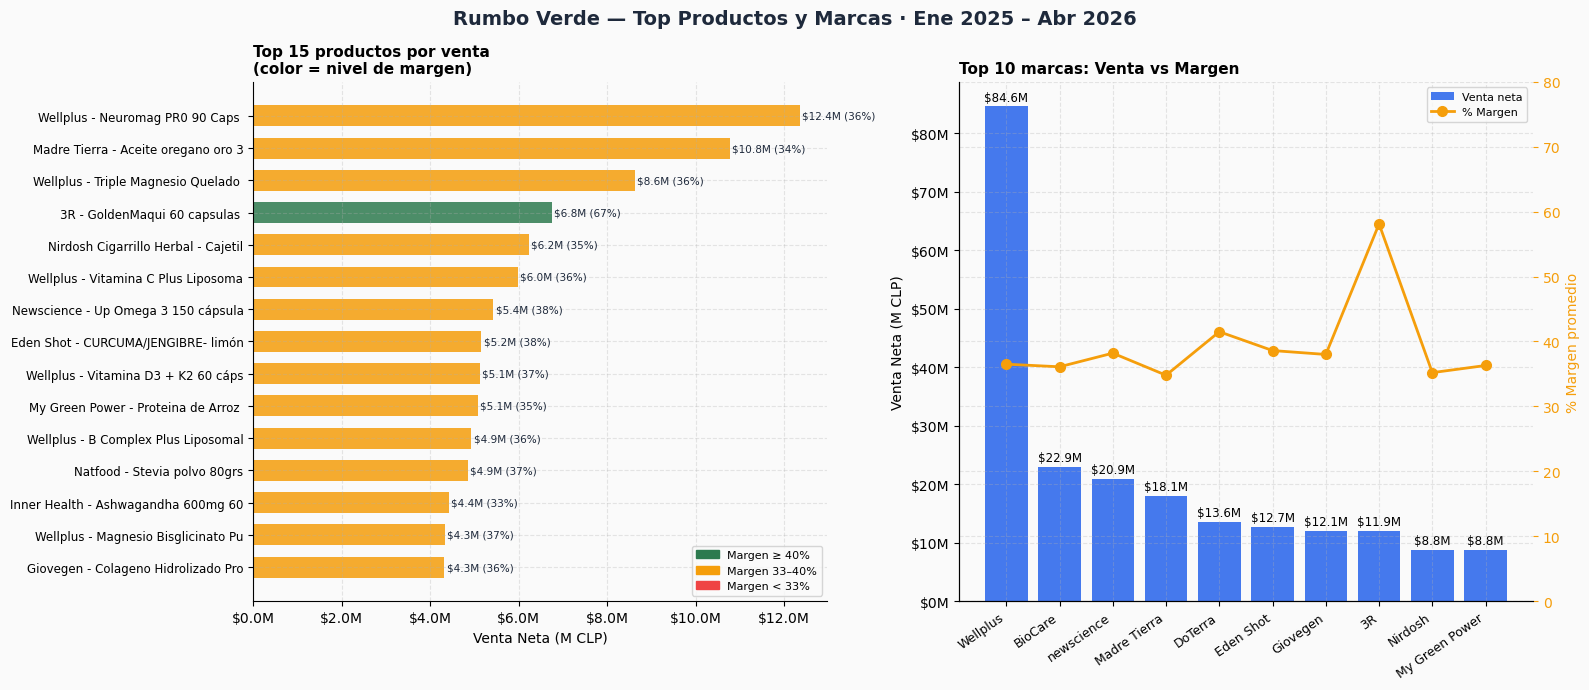

✅ Gráfico guardado en outputs/


In [35]:
# ─────────────────────────────────────────────────
# PASO 5 — Gráfico productos y marcas
# ─────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Rumbo Verde — Top Productos y Marcas · Ene 2025 – Abr 2026',
             fontsize=14, fontweight='bold', color='#1E293B')

# ── Gráfico 1: Top 15 productos ──
# Coloreamos por nivel de margen
# Verde = margen alto, Naranja = medio, Rojo = bajo
ax1 = axes[0]
colores_prod = [
    VERDE  if m >= 40 else
    NARANJ if m >= 33 else
    ROJO
    for m in top15['margen_pct']
]
top15['label'] = top15['Producto / Servicio'].str[:35]
ax1.barh(top15['label'][::-1], top15['venta_M'][::-1],
         color=colores_prod[::-1], height=0.65, alpha=0.85)
ax1.set_xlabel('Venta Neta (M CLP)', fontsize=10)
ax1.set_title('Top 15 productos por venta\n(color = nivel de margen)',
              fontsize=11, fontweight='bold', loc='left')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax1.tick_params(axis='y', labelsize=8.5)

# Agregar valor al final de cada barra
for i, (v, m) in enumerate(zip(top15['venta_M'][::-1], top15['margen_pct'][::-1])):
    ax1.text(v + 0.05, i, f'${v:.1f}M ({m:.0f}%)',
             va='center', fontsize=7.5, color='#1E293B')

from matplotlib.patches import Patch
leyenda = [
    Patch(color=VERDE,  label='Margen ≥ 40%'),
    Patch(color=NARANJ, label='Margen 33–40%'),
    Patch(color=ROJO,   label='Margen < 33%'),
]
ax1.legend(handles=leyenda, fontsize=8, loc='lower right')

# ── Gráfico 2: Top 10 marcas ──
# Doble eje: barras para venta, línea para margen
ax2 = axes[1]
top10m = top_marcas.head(10)
x = np.arange(len(top10m))

barras = ax2.bar(x, top10m['venta_M'], color=AZUL, alpha=0.85, label='Venta neta')
ax2r = ax2.twinx()
ax2r.plot(x, top10m['margen_pct'], color=NARANJ, marker='o',
          linewidth=2, markersize=7, label='% Margen')
ax2r.set_ylabel('% Margen promedio', fontsize=10, color=NARANJ)
ax2r.tick_params(axis='y', colors=NARANJ)
ax2r.spines['top'].set_visible(False)
ax2r.set_ylim(0, 80)

# Valor encima de cada barra
for bar in barras:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.5,
             f'${h:.1f}M', ha='center', va='bottom', fontsize=8.5)

ax2.set_xticks(x)
ax2.set_xticklabels(top10m['Marca'], rotation=35, ha='right', fontsize=9)
ax2.set_ylabel('Venta Neta (M CLP)', fontsize=10)
ax2.set_title('Top 10 marcas: Venta vs Margen',
              fontsize=11, fontweight='bold', loc='left')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))

lines1, lab1 = ax2.get_legend_handles_labels()
lines2, lab2 = ax2r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, lab1 + lab2, fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'rv_productos_marcas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado en outputs/")

In [36]:
# ─────────────────────────────────────────────────
# PASO 6 — Patrones de venta
# ─────────────────────────────────────────────────

# Extraemos la hora de venta desde la columna Hora Venta
ventas['hora'] = ventas['Hora Venta'].astype(str).str[:2].astype(int)

# Ventas por día de semana
dias_order = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

por_dia = ventas.groupby('dia_semana').agg(
    venta_neta = ('Venta Total Neta', 'sum'),
    boletas    = ('Numero del documento', 'nunique')
).reindex(dias_order).reset_index()
por_dia['venta_M']        = (por_dia['venta_neta'] / 1e6).round(2)
por_dia['ticket_promedio'] = (por_dia['venta_neta'] / por_dia['boletas']).round(0)

# Ventas por hora
por_hora = ventas.groupby('hora').agg(
    venta_neta = ('Venta Total Neta', 'sum'),
    boletas    = ('Numero del documento', 'nunique')
).reset_index()
por_hora['venta_M'] = (por_hora['venta_neta'] / 1e6).round(2)

print("=== VENTAS POR DÍA DE SEMANA ===")
print(por_dia[['dia_semana','venta_M','boletas','ticket_promedio']].to_string(index=False))
print()
print("=== VENTAS POR HORA ===")
print(por_hora[['hora','venta_M','boletas']].to_string(index=False))

=== VENTAS POR DÍA DE SEMANA ===
dia_semana  venta_M  boletas  ticket_promedio
     Lunes    80.36     2584          31097.0
    Martes    76.95     2496          30827.0
 Miércoles    70.08     2430          28840.0
    Jueves    67.16     2271          29574.0
   Viernes    66.29     2307          28735.0
    Sábado    64.68     2299          28134.0
   Domingo    53.85     1946          27671.0

=== VENTAS POR HORA ===
 hora  venta_M  boletas
    8     4.28      165
    9    33.04     1091
   10    63.54     1940
   11    63.51     2070
   12    59.20     1925
   13    52.92     1605
   14    40.00     1369
   15    39.07     1420
   16    43.03     1630
   17    42.61     1636
   18    28.77     1110
   19     8.76      346
   20     0.64       25


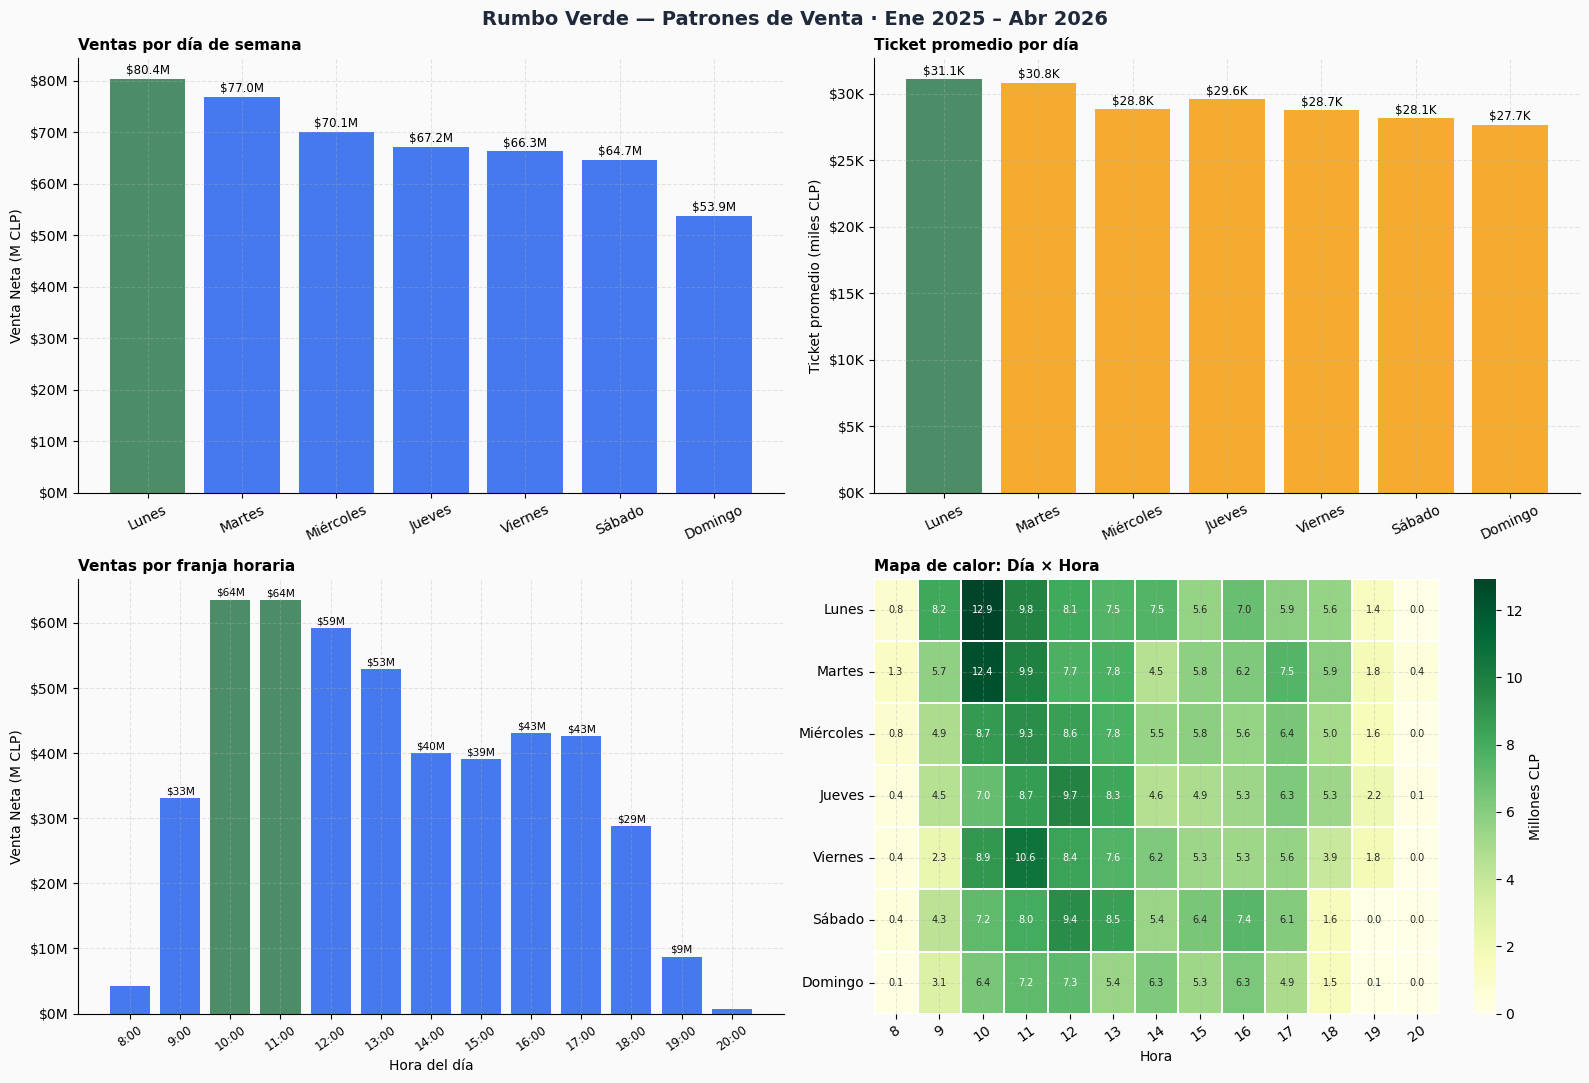

✅ Gráfico guardado en outputs/


In [37]:
# ─────────────────────────────────────────────────
# PASO 6 — Gráfico de patrones de venta
# ─────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Rumbo Verde — Patrones de Venta · Ene 2025 – Abr 2026',
             fontsize=14, fontweight='bold', color='#1E293B')

# ── Gráfico 1: Ventas por día de semana ──
ax1 = axes[0, 0]
# El día con más ventas va en verde, el resto en azul
colores_dia = [VERDE if d == 'Lunes' else AZUL for d in por_dia['dia_semana']]
barras = ax1.bar(por_dia['dia_semana'], por_dia['venta_M'],
                 color=colores_dia, alpha=0.85)
ax1.set_title('Ventas por día de semana', fontsize=11, fontweight='bold', loc='left')
ax1.set_ylabel('Venta Neta (M CLP)', fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax1.tick_params(axis='x', rotation=25)
for bar in barras:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.3,
             f'${h:.1f}M', ha='center', va='bottom', fontsize=8.5)

# ── Gráfico 2: Ticket promedio por día ──
ax2 = axes[0, 1]
colores_ticket = [VERDE if d == 'Lunes' else NARANJ for d in por_dia['dia_semana']]
barras2 = ax2.bar(por_dia['dia_semana'], por_dia['ticket_promedio'] / 1000,
                  color=colores_ticket, alpha=0.85)
ax2.set_title('Ticket promedio por día', fontsize=11, fontweight='bold', loc='left')
ax2.set_ylabel('Ticket promedio (miles CLP)', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax2.tick_params(axis='x', rotation=25)
for bar in barras2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.1,
             f'${h:.1f}K', ha='center', va='bottom', fontsize=8.5)

# ── Gráfico 3: Ventas por hora ──
ax3 = axes[1, 0]
colores_hora = [VERDE if h in [10, 11] else AZUL for h in por_hora['hora']]
barras3 = ax3.bar(por_hora['hora'], por_hora['venta_M'],
                  color=colores_hora, alpha=0.85)
ax3.set_title('Ventas por franja horaria', fontsize=11, fontweight='bold', loc='left')
ax3.set_xlabel('Hora del día', fontsize=10)
ax3.set_ylabel('Venta Neta (M CLP)', fontsize=10)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax3.set_xticks(por_hora['hora'])
ax3.set_xticklabels([f'{h}:00' for h in por_hora['hora']], rotation=35, fontsize=8.5)
for bar in barras3:
    h = bar.get_height()
    if h > 5:
        ax3.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                 f'${h:.0f}M', ha='center', va='bottom', fontsize=7.5)

# ── Gráfico 4: Heatmap día × hora ──
# El heatmap muestra en un solo vistazo cuándo se vende más
# Colores más oscuros = más ventas
ax4 = axes[1, 1]
ventas['dia_num'] = ventas['fecha_dt'].dt.dayofweek
pivot = ventas.pivot_table(
    values='Venta Total Neta',
    index='dia_num',
    columns='hora',
    aggfunc='sum',
    fill_value=0
)
pivot.index = [dias_order[i] for i in pivot.index]
sns.heatmap(pivot / 1e6, ax=ax4, cmap='YlGn', linewidths=0.3,
            fmt='.1f', annot=True, annot_kws={'size': 7},
            cbar_kws={'label': 'Millones CLP'})
ax4.set_title('Mapa de calor: Día × Hora', fontsize=11, fontweight='bold', loc='left')
ax4.set_xlabel('Hora', fontsize=10)
ax4.set_ylabel('')
ax4.tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'rv_patrones.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado en outputs/")